In [ ]:
# import pandas as pd

# df = pd.read_csv('participants.csv', sep='\t')

# # Check the unique values in the genetic columns
# print("APOE_haplotype unique values:", df['APOE_haplotype'].unique())
# print("PICALM_rs3851179 unique values:", df['PICALM_rs3851179'].unique())

# # Function to check if APOE ε4 is present (e3/e4, e4/e4, e2/e4, etc.)
# def has_apoe_e4(haplotype):
#     if pd.isna(haplotype):
#         return None
#     return 'e4' in str(haplotype).lower()

# # Function to check if PICALM has risky G/G genotype
# # G/G = risk present (True), G/A or A/A = no risk (False)
# def has_picalm_gg(genotype):
#     if pd.isna(genotype):
#         return None
#     genotype = str(genotype).upper().replace(" ", "")
#     return genotype == 'G/G'

# # Check for ambiguous e2/e4 genotype (to be excluded)
# def is_ambiguous_apoe(haplotype):
#     if pd.isna(haplotype):
#         return False
#     h = str(haplotype).lower()
#     return 'e2' in h and 'e4' in h  # e2/e4 is ambiguous

# # Create risk flags
# df['APOE_e4_present'] = df['APOE_haplotype'].apply(has_apoe_e4)
# df['PICALM_GG'] = df['PICALM_rs3851179'].apply(has_picalm_gg)
# df['ambiguous_apoe'] = df['APOE_haplotype'].apply(is_ambiguous_apoe)

# # Assign labels based on paper criteria
# def assign_label(row):
#     if row['ambiguous_apoe']:
#         return None  # Exclude e2/e4
    
#     apoe = row['APOE_e4_present']
#     picalm_gg = row['PICALM_GG']
    
#     if pd.isna(apoe) or pd.isna(picalm_gg):
#         return None  # Missing genetic data
    
#     if apoe and picalm_gg:
#         return 2  # A+P+ (double risk: APOE-ε4 + PICALM G/G)
#     elif apoe and not picalm_gg:
#         return 1  # A+P- (single risk: APOE-ε4 only)
#     else:
#         return 0  # N (no significant risk)

# df['genetic_label'] = df.apply(assign_label, axis=1)

# # Map labels to names
# LABEL_MAP = {0: "N", 1: "A+P-", 2: "A+P+"}
# df['genetic_label_name'] = df['genetic_label'].map(LABEL_MAP)

# # Display results
# print("\n--- Excluded (ambiguous e2/e4) ---")
# print(df[df['ambiguous_apoe']][['participant_id', 'APOE_haplotype', 'PICALM_rs3851179']])

# print("\n--- Label Distribution ---")
# print(df['genetic_label_name'].value_counts())

# # Show sample of data
# print("\n--- Sample Data ---")
# print(df[['participant_id', 'APOE_haplotype', 'PICALM_rs3851179', 
#           'APOE_e4_present', 'PICALM_GG', 'genetic_label', 
#           'genetic_label_name']].head(20))

In [ ]:
# import os
# import glob
# import pandas as pd
# from pathlib import Path

# # ─── Load CSV data and create genetic labels ───
# df = pd.read_csv('participants.csv', sep='\t')

# # Function to check if APOE ε4 is present
# def has_apoe_e4(haplotype):
#     if pd.isna(haplotype):
#         return None
#     return 'e4' in str(haplotype).lower()

# # Function to check if PICALM has risky G/G genotype
# def has_picalm_gg(genotype):
#     if pd.isna(genotype):
#         return None
#     genotype = str(genotype).upper().replace(" ", "")
#     return genotype == 'G/G'

# # Check for ambiguous e2/e4 genotype
# def is_ambiguous_apoe(haplotype):
#     if pd.isna(haplotype):
#         return False
#     h = str(haplotype).lower()
#     return 'e2' in h and 'e4' in h

# # Create risk flags
# df['APOE_e4_present'] = df['APOE_haplotype'].apply(has_apoe_e4)
# df['PICALM_GG'] = df['PICALM_rs3851179'].apply(has_picalm_gg)
# df['ambiguous_apoe'] = df['APOE_haplotype'].apply(is_ambiguous_apoe)

# # Assign labels
# def assign_label(row):
#     if row['ambiguous_apoe']:
#         return None
#     apoe = row['APOE_e4_present']
#     picalm_gg = row['PICALM_GG']
#     if pd.isna(apoe) or pd.isna(picalm_gg):
#         return None
#     if apoe and picalm_gg:
#         return 2  # A+P+
#     elif apoe and not picalm_gg:
#         return 1  # A+P-
#     else:
#         return 0  # N

# df['genetic_label'] = df.apply(assign_label, axis=1)
# LABEL_MAP = {0: "N", 1: "A+P-", 2: "A+P+"}
# df['genetic_label_name'] = df['genetic_label'].map(LABEL_MAP)

# # Get subject IDs from CSV
# csv_subjects = set()
# for pid in df['participant_id'].dropna():
#     csv_subjects.add(str(pid).replace('sub-', ''))

# print(f"Subjects in CSV: {len(csv_subjects)}")

# # ─── Get subjects from fMRI folder ───
# BASE_DIR = "/data/s.dharia-ra/PEARL/fMRI-PEARL/backup_preprocssed_files/derivatives"

# fmri_subjects_pa = set()
# fmri_subjects_ap = set()

# for fp in glob.glob(os.path.join(BASE_DIR, "sub-*/func/sub-*_task-rest_dir-PA*desc-preproc_bold.nii.gz")):
#     fmri_subjects_pa.add(Path(fp).parent.parent.name.replace("sub-", ""))

# for fp in glob.glob(os.path.join(BASE_DIR, "sub-*/func/sub-*_task-rest_dir-AP*desc-preproc_bold.nii.gz")):
#     fmri_subjects_ap.add(Path(fp).parent.parent.name.replace("sub-", ""))

# fmri_subjects_both = fmri_subjects_pa & fmri_subjects_ap
# common_subjects = csv_subjects & fmri_subjects_both

# print(f"Subjects with PA data: {len(fmri_subjects_pa)}")
# print(f"Subjects with AP data: {len(fmri_subjects_ap)}")
# print(f"Subjects with BOTH PA & AP: {len(fmri_subjects_both)}")
# print(f"\n✓ Common subjects (CSV + PA + AP): {len(common_subjects)}")

# # ─── Check valid genetic labels ───
# df_common = df[df['participant_id'].apply(lambda x: str(x).replace('sub-', '') in common_subjects)]
# df_valid = df_common[df_common['genetic_label'].notna()]

# print(f"\n--- Subjects with valid genetic labels: {len(df_valid)} ---")
# print(df_valid['genetic_label_name'].value_counts())

# # ─── List common subjects with their labels ───
# print(f"\n--- Common subjects with labels ---")
# for sid in sorted(common_subjects)[:20]:
#     row = df[df['participant_id'].apply(lambda x: str(x).replace('sub-', '') == sid)]
#     if not row.empty:
#         label = row['genetic_label_name'].values[0]
#         apoe = row['APOE_haplotype'].values[0]
#         picalm = row['PICALM_rs3851179'].values[0]
#         print(f"  {sid}: {label} (APOE={apoe}, PICALM={picalm})")

In [ ]:

#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
dynamic_fc_full_analysis.py
──────────────────────────—
Pipeline from 4D fMRI (PA & AP) → dynamic‐FC → two‐way ANOVA on dwell times.
"""

import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from joblib import Parallel, delayed

from nilearn.input_data import NiftiLabelsMasker
from nilearn.connectome import ConnectivityMeasure

from sklearn.cluster import KMeans

import statsmodels.api as sm
from statsmodels.formula.api import ols

# ─── 1. USER PARAMETERS ───────────────────────────────
BASE_DIR = "/data/s.dharia-ra/PEARL/fMRI-PEARL/backup_preprocssed_files/derivatives"

N_JOBS   = 32         # for Parallel
# WIN_LEN  = 37         # volumes (30)
# STEP     = 9         # volumes 25 percent overlap
TR       = 0.8        # seconds per volume
# TR = 0.8
WIN_SEC = 30
# 75 overlaping
OVERLAP_FRAC = 0.75 # 25 percent overlap

WIN_LEN = int(round(WIN_SEC / TR))          # 125
STEP    = int(round(WIN_LEN * (1.0 - OVERLAP_FRAC)))  # 112 # rational was that we need more windows!
# print(STEP)
OUT_DIR = Path("subject_windows_confounds_old_30sec")

LABEL_MAP= {0:"N", 1:"A+P-", 2:"A+P+"}
ATLAS_IMG = (
    "/home/s.dharia-ra/.cache/templateflow/tpl-MNI152NLin2009cAsym/tpl-MNI152NLin2009cAsym_res-02_atlas-Schaefer2018_desc-100Parcels7Networks_dseg.nii.gz"
)

# ─── CHANGED: Confounds list (motion + aCompCor K=5) ─────────────────
N_ACOMPCOR = 5
minimal_want = [
    'trans_x','trans_y','trans_z','rot_x','rot_y','rot_z'
] + [f'a_comp_cor_{i:02d}' for i in range(N_ACOMPCOR)
]


# ─── LOAD CSV AND CREATE GENETIC LABELS ───────────────
df = pd.read_csv('participants.csv', sep='\t')

def has_apoe_e4(haplotype):
    if pd.isna(haplotype):
        return None
    return 'e4' in str(haplotype).lower()

def has_picalm_gg(genotype):
    if pd.isna(genotype):
        return None
    genotype = str(genotype).upper().replace(" ", "")
    return genotype == 'G/G'

def is_ambiguous_apoe(haplotype):
    if pd.isna(haplotype):
        return False
    h = str(haplotype).lower()
    return 'e2' in h and 'e4' in h

df['APOE_e4_present'] = df['APOE_haplotype'].apply(has_apoe_e4)
df['PICALM_GG'] = df['PICALM_rs3851179'].apply(has_picalm_gg)
df['ambiguous_apoe'] = df['APOE_haplotype'].apply(is_ambiguous_apoe)

def assign_label(row):
    if row['ambiguous_apoe']:
        return None
    apoe = row['APOE_e4_present']
    picalm_gg = row['PICALM_GG']
    if pd.isna(apoe) or pd.isna(picalm_gg):
        return None
    if apoe and picalm_gg:
        return 2  # A+P+
    elif apoe and not picalm_gg:
        return 1  # A+P-
    else:
        return 0  # N

df['genetic_label'] = df.apply(assign_label, axis=1)

# Create lookup dictionary: subject_id -> label
subject_labels = {}
for _, row in df.iterrows():
    if pd.notna(row['genetic_label']):
        sid = str(row['participant_id']).replace('sub-', '')
        subject_labels[sid] = int(row['genetic_label'])

print(f"Subjects with valid genetic labels: {len(subject_labels)}")






def build_minimal_confounds(conf_path):
    """Build confounds matrix from TSV file (fail-fast, no fillna, z-score confounds)."""
    if conf_path is None or not Path(conf_path).exists():
        raise FileNotFoundError(f"Confounds file not found: {conf_path}")

    cdf = pd.read_csv(conf_path, sep="\t")

    cols = [c for c in minimal_want if c in cdf.columns]
    if len(cols) != len(minimal_want):
        missing = [c for c in minimal_want if c not in cdf.columns]
        raise ValueError(f"Missing confound columns in {conf_path}: {missing}")

    if cdf[cols].isna().any().any():
        bad_cols = list(cdf[cols].columns[cdf[cols].isna().any()])
        raise ValueError(f"NaNs found in confounds columns {bad_cols} in {conf_path} (no silent fill).")

    mat = cdf[cols].astype(float).values

    # z-score each confound (numerically stable regression); fail-fast on zero std
    mu = mat.mean(axis=0)
    sd = mat.std(axis=0)
    if (sd == 0).any():
        zero_cols = [cols[i] for i in range(len(cols)) if sd[i] == 0]
        raise ValueError(f"Zero-std confound columns in {conf_path}: {zero_cols}")
    mat = (mat - mu) / sd

    return mat

def get_confounds_path(fmri_path, tech):
    """Get corresponding confounds file path"""
    subj_dir = Path(fmri_path).parent.parent
    sid = subj_dir.name
    confounds_file = subj_dir / "func" / f"{sid}_task-rest_dir-{tech}_desc-confounds_timeseries.tsv"
    return confounds_file if confounds_file.exists() else None

# ─── 2. GATHER BOTH PA & AP RUNS (only subjects with valid labels) ───────────────────────
runs = []
skipped_subjects = set()

for pat, tech in [
    (os.path.join(BASE_DIR, "sub-*/func/sub-*_task-rest_dir-PA*desc-preproc_bold.nii.gz"), "PA"),
    (os.path.join(BASE_DIR, "sub-*/func/sub-*_task-rest_dir-AP*desc-preproc_bold.nii.gz"), "AP"),
]:
    for fp in sorted(glob.glob(pat)):
        subj_dir = Path(fp).parent.parent
        sid = subj_dir.name.replace("sub-", "")

        if sid not in subject_labels:
            skipped_subjects.add(sid)
            continue

        lab = subject_labels[sid]
        conf_path = get_confounds_path(fp, tech)
        runs.append((fp, sid, LABEL_MAP[lab], tech, conf_path))

print(f"Found {len(runs)} total runs ({len(runs)//2} subjects × 2 techniques)")
if skipped_subjects:
    print(f"Skipped {len(skipped_subjects)} subjects without valid genetic labels")

# Keep a 5-field version for anything needing conf_path later
runs_with_conf = runs

# ─── 3. ROI TIME‐SERIES EXTRACTION WITH CONFOUNDS ────────────────────
masker = NiftiLabelsMasker(
    labels_img=ATLAS_IMG,
    standardize=False,
    detrend=True,
    t_r=TR,
    low_pass=0.1,
    high_pass=0.01,
    memory="nilearn_cache",
    memory_level=1,
)

def load_ts_with_confounds(fp, conf_path):
    """Load time series with confounds regression"""
    confounds = build_minimal_confounds(conf_path)
    time_series = masker.fit_transform(fp, confounds=confounds)
    return time_series

print("Extracting ROI time-series for each run with confounds regression…")
ts_list = Parallel(n_jobs=N_JOBS)(
    delayed(load_ts_with_confounds)(fp, conf_path)
    for fp, _, _, _, conf_path in runs_with_conf
)

# Print some diagnostics
for i, ((fp, sid, grp, tech, conf_path), ts) in enumerate(zip(runs_with_conf, ts_list)):
    print(f"Subject {sid} ({tech}): {ts.shape[0]} timepoints, {ts.shape[1]} parcels")
    if i >= 3:
        break

# ─── 4. SLIDING‐WINDOW FC ─────────────────────────────
conn = ConnectivityMeasure(kind="correlation", vectorize=True, discard_diagonal=True)
all_windows = []
sub_idx     = []
start = 0

print("Computing sliding‐window FC…")
for i, ts in enumerate(ts_list):
    n_vols = ts.shape[0]
    n_win  = int(1 + (n_vols - WIN_LEN)//STEP)
    mats   = []
    for w in range(n_win):
        sl = slice(w*STEP, w*STEP + WIN_LEN)
        conn_mat  = conn.fit_transform([ts[sl]])[0]
        mats.append(conn_mat)
    mats = np.vstack(mats)
    all_windows.append(mats)
    sub_idx.append((i, start, start + n_win))
    start += n_win

X = np.vstack(all_windows)
print(f"Final connectivity matrix shape: {X.shape}")

# Update runs list format for compatibility with downstream code
runs_updated = [(fp, sid, lab, tech) for fp, sid, lab, tech, _ in runs_with_conf]
runs = runs_updated

# ─── 5. GROUP BY SUBJECT & SAVE TO NPZ ───────────────────────────────────
from pathlib import Path

OUT_DIR.mkdir(exist_ok=True, parents=True)

# Create reverse mapping for display purposes
REVERSE_LABEL_MAP = {v: k for k, v in LABEL_MAP.items()}  # {'N': 0, 'A+P-': 1, 'A+P+': 2}

# Collect per-subject windows
subject_data = {}
for i, (fp, sid, lab, tech) in enumerate(runs):
    # Get the windows for this run
    _, start_idx, end_idx = sub_idx[i]
    run_windows = X[start_idx:end_idx]  # Shape: (n_windows_for_this_run, n_edges)
    
    # Initialize dict for this subject if not exists
    if sid not in subject_data:
        # Convert string label back to numeric if needed
        if isinstance(lab, str):
            numeric_label = REVERSE_LABEL_MAP[lab]
        else:
            numeric_label = lab
        subject_data[sid] = {"label": numeric_label}  # Store the numeric label
    
    # Store windows for this technique (PA or AP)
    subject_data[sid][tech] = run_windows

# Save each subject as a compressed NPZ file
for sid, data in subject_data.items():
    npz_path = OUT_DIR / f"sub-{sid}_windows.npz"
    
    # Prepare data for saving
    save_dict = {
        "label": data["label"]  # Numeric label (0, 1, or 2)
    }
    
    # Add PA and AP data if they exist
    if "PA" in data:
        save_dict["PA"] = data["PA"]
    if "AP" in data:
        save_dict["AP"] = data["AP"]
    
    # Save compressed NPZ
    np.savez_compressed(npz_path, **save_dict)
    
    # Print summary
    pa_shape = data.get("PA", np.array([])).shape
    ap_shape = data.get("AP", np.array([])).shape
    print(f"Saved subject {sid} → {npz_path}")
    print(f"  Label: {data['label']} ({LABEL_MAP[data['label']]})")  # Now uses numeric key
    print(f"  PA windows: {pa_shape}")
    print(f"  AP windows: {ap_shape}")

print(f"\n✓ All subject data saved to: {OUT_DIR}")

# ─── 6. VERIFICATION: LOAD AND CHECK ONE SUBJECT ─────────────────────────
# Example of how to load the data later
example_subject = list(subject_data.keys())[0]
example_path = OUT_DIR / f"sub-{example_subject}_windows.npz"

loaded = np.load(example_path)
print(f"\n📁 Example loaded data for subject {example_subject}:")
print(f"  Available keys: {list(loaded.keys())}")

# Extract scalar value from numpy array
label_value = loaded['label'].item()  # Convert 0-d array to scalar
print(f"  Label: {label_value} ({LABEL_MAP[label_value]})")

if 'PA' in loaded:
    print(f"  PA shape: {loaded['PA'].shape}")
if 'AP' in loaded:
    print(f"  AP shape: {loaded['AP'].shape}")

loaded.close()  # Good practice to close the NPZ file


Subjects with valid genetic labels: 189
Found 136 total runs (68 subjects × 2 techniques)
Skipped 1 subjects without valid genetic labels
Extracting ROI time-series for each run with confounds regression…
Subject 01 (PA): 560 timepoints, 100 parcels
Subject 02 (PA): 560 timepoints, 100 parcels
Subject 03 (PA): 560 timepoints, 100 parcels
Subject 04 (PA): 560 timepoints, 100 parcels
Computing sliding‐window FC…
Final connectivity matrix shape: (7208, 4950)
Saved subject 01 → subject_windows_confounds_old_30sec/sub-01_windows.npz
  Label: 0 (N)
  PA windows: (53, 4950)
  AP windows: (53, 4950)
Saved subject 02 → subject_windows_confounds_old_30sec/sub-02_windows.npz
  Label: 0 (N)
  PA windows: (53, 4950)
  AP windows: (53, 4950)
Saved subject 03 → subject_windows_confounds_old_30sec/sub-03_windows.npz
  Label: 0 (N)
  PA windows: (53, 4950)
  AP windows: (53, 4950)
Saved subject 04 → subject_windows_confounds_old_30sec/sub-04_windows.npz
  Label: 0 (N)
  PA windows: (53, 4950)
  AP wind

In [4]:
# read tsv files
df = pd.read_csv("/data/s.dharia-ra/PEARL/fMRI-PEARL/backup_preprocssed_files/derivatives/sub-80/func/sub-80_task-rest_dir-AP_desc-confounds_timeseries.tsv", sep='\t')

print(df.columns)
for col in df.columns:
    print(f"{col}")

Index(['global_signal', 'global_signal_derivative1', 'global_signal_power2',
       'global_signal_derivative1_power2', 'csf', 'csf_derivative1',
       'csf_derivative1_power2', 'csf_power2', 'white_matter',
       'white_matter_derivative1',
       ...
       'rot_x_derivative1_power2', 'rot_x_power2', 'rot_y',
       'rot_y_derivative1', 'rot_y_derivative1_power2', 'rot_y_power2',
       'rot_z', 'rot_z_derivative1', 'rot_z_derivative1_power2',
       'rot_z_power2'],
      dtype='object', length=535)
global_signal
global_signal_derivative1
global_signal_power2
global_signal_derivative1_power2
csf
csf_derivative1
csf_derivative1_power2
csf_power2
white_matter
white_matter_derivative1
white_matter_power2
white_matter_derivative1_power2
csf_wm
tcompcor
std_dvars
dvars
framewise_displacement
rmsd
t_comp_cor_00
t_comp_cor_01
t_comp_cor_02
t_comp_cor_03
t_comp_cor_04
c_comp_cor_00
c_comp_cor_01
c_comp_cor_02
c_comp_cor_03
c_comp_cor_04
c_comp_cor_05
c_comp_cor_06
c_comp_cor_07
c_comp_cor

Saved subject 01 → subject_windows_confounds_all_60sec_compCor1/sub-01_windows.npz
  Label: 0 (N)
  PA windows: (59, 4950)
  AP windows: (59, 4950)
Saved subject 02 → subject_windows_confounds_all_60sec_compCor1/sub-02_windows.npz
  Label: 0 (N)
  PA windows: (59, 4950)
  AP windows: (59, 4950)
Saved subject 03 → subject_windows_confounds_all_60sec_compCor1/sub-03_windows.npz
  Label: 0 (N)
  PA windows: (59, 4950)
  AP windows: (59, 4950)
Saved subject 04 → subject_windows_confounds_all_60sec_compCor1/sub-04_windows.npz
  Label: 0 (N)
  PA windows: (59, 4950)
  AP windows: (59, 4950)
Saved subject 05 → subject_windows_confounds_all_60sec_compCor1/sub-05_windows.npz
  Label: 0 (N)
  PA windows: (59, 4950)
  AP windows: (59, 4950)
Saved subject 07 → subject_windows_confounds_all_60sec_compCor1/sub-07_windows.npz
  Label: 0 (N)
  PA windows: (59, 4950)
  AP windows: (59, 4950)
Saved subject 08 → subject_windows_confounds_all_60sec_compCor1/sub-08_windows.npz
  Label: 0 (N)
  PA windows: 


Loading example subject data from: subject_windows_confounds_all_60sec_compCor1/sub-01_windows.npz
PA data shape: (59, 4950)
Label: 0 (N)
Plotting window 1
Plotting window 2
Plotting window 3


/tmp/ipykernel_772671/4064930656.py:53: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


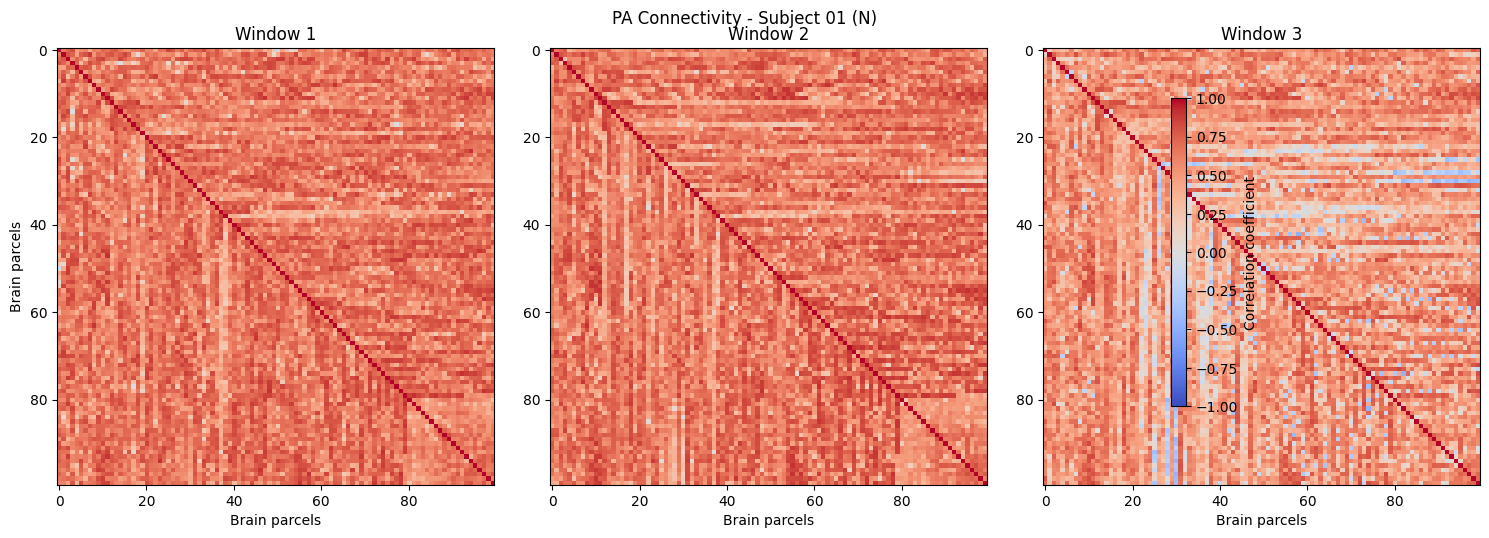

In [25]:
import matplotlib.pyplot as plt
import numpy as np

# Load the data
example_subject = list(subject_data.keys())[0]
example_path = OUT_DIR / f"sub-{example_subject}_windows.npz"
print(f"\nLoading example subject data from: {example_path}")

loaded = np.load(example_path)
PA_data = loaded.get('PA', None)
AP_data = loaded.get('AP', None)
label = loaded['label'].item()

print(f"PA data shape: {PA_data.shape}")
print(f"Label: {label} ({LABEL_MAP[label]})")

# Convert vectorized connectivity back to matrix form
def vec_to_matrix(vec, n_parcels=100):
    """Convert vectorized connectivity to full symmetric matrix"""
    # Create empty matrix
    matrix = np.zeros((n_parcels, n_parcels))
    
    # Fill upper triangle (excluding diagonal)
    idx = np.triu_indices(n_parcels, k=1)
    matrix[idx] = vec
    
    # Make symmetric
    matrix = matrix + matrix.T
    
    # Fill diagonal with 1s (self-connectivity)
    np.fill_diagonal(matrix, 1)
    
    return matrix

# Plot first few windows
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
j = 10
for i in range(min(3, PA_data.shape[0])):  # Plot up to 3 windows
    print(f"Plotting window {i+1}")

    window_vec = PA_data[j + i]
    window_matrix = vec_to_matrix(window_vec)
    
    im = axes[i].imshow(window_matrix, vmin=-1, vmax=1, cmap='coolwarm')
    axes[i].set_title(f'Window {i+1}')
    axes[i].set_xlabel('Brain parcels')
    if i == 0:
        axes[i].set_ylabel('Brain parcels')

# Add shared colorbar
fig.colorbar(im, ax=axes, shrink=0.8, label='Correlation coefficient')
plt.suptitle(f'PA Connectivity - Subject {example_subject} ({LABEL_MAP[label]})')
plt.tight_layout()
plt.show()

In [18]:
# Cell 1 — imports
import json
import re
from pathlib import Path
import pandas as pd
# Cell 2 — helpers (simple + fail-fast)

A_COMP_RE = re.compile(r"^a_comp_cor_(\d+)$")

def confounds_json_from_tsv(conf_tsv_path: Path) -> Path:
    conf_tsv_path = Path(conf_tsv_path)
    if conf_tsv_path.suffix.lower() != ".tsv":
        raise ValueError(f"Expected a .tsv confounds path, got: {conf_tsv_path}")
    conf_json_path = conf_tsv_path.with_suffix(".json")
    if not conf_json_path.exists():
        raise FileNotFoundError(f"Missing confounds JSON sidecar: {conf_json_path}")
    return conf_json_path

def _extract_variance_explained(meta_entry: dict) -> float:
    # Different fMRIPrep versions can use different keys; we try common ones.
    for k in ["VarianceExplained", "variance_explained", "ExplainedVariance", "explained_variance"]:
        if k in meta_entry:
            v = meta_entry[k]
            if v is None:
                break
            return float(v)
    raise ValueError(f"No variance-explained field found. Available keys: {sorted(meta_entry.keys())}")

def load_a_compcor_table(conf_tsv_path: Path, units: str = "fraction") -> pd.DataFrame:
    """
    units:
      - 'fraction' expects values in [0,1]
      - 'percent'  expects values in [0,100], will be divided by 100
    """
    conf_json = confounds_json_from_tsv(conf_tsv_path)
    meta = json.loads(conf_json.read_text())

    rows = []
    for name, info in meta.items():
        m = A_COMP_RE.match(name)
        if not m:
            continue
        idx = int(m.group(1))
        if not isinstance(info, dict):
            raise ValueError(f"JSON entry for {name} is not a dict.")
        ve = _extract_variance_explained(info)
        rows.append((idx, name, ve))

    if not rows:
        raise ValueError(f"No a_comp_cor_* entries found in: {conf_json}")

    rows.sort(key=lambda x: x[0])
    df = pd.DataFrame(rows, columns=["idx", "name", "var_explained_raw"])

    if units not in ("fraction", "percent"):
        raise ValueError("units must be 'fraction' or 'percent'")

    vmax = float(df["var_explained_raw"].max())

    if units == "fraction":
        if vmax > 1.0 + 1e-6:
            raise ValueError(
                f"Found variance values > 1 (max={vmax}). If your JSON stores percent, set units='percent'."
            )
        df["var_explained"] = df["var_explained_raw"]
    else:
        if vmax > 100.0 + 1e-6:
            raise ValueError(
                f"Found variance values > 100 (max={vmax}). If your JSON stores fraction, set units='fraction'."
            )
        df["var_explained"] = df["var_explained_raw"] / 100.0

    df["cum_var"] = df["var_explained"].cumsum()
    return df[["name", "var_explained", "cum_var"]]

def k_for_target(df_compcor: pd.DataFrame, target: float = 0.50) -> int:
    if not (0.0 < target <= 1.0):
        raise ValueError("target must be in (0, 1]. Example: 0.50")
    hit = df_compcor.index[df_compcor["cum_var"] >= target]
    return int(hit[0] + 1) if len(hit) else int(len(df_compcor))

# Cell 3 — run for ONE example run (uses your `runs` list from the big script)

# pick the first run that has a confounds TSV path
example = "/data/s.dharia-ra/PEARL/fMRI-PEARL/backup_preprocssed_files/derivatives/sub-80/func/sub-80_task-rest_dir-AP_desc-confounds_timeseries.tsv"
rows = []
for item in runs:
    if len(item) == 5:
        fp, sid, grp, tech, conf_path = item
    elif len(item) == 4:
        fp, sid, grp, tech = item
        conf_path = get_confounds_path(fp, tech)
    else:
        raise ValueError(f"Unexpected runs tuple length: {len(item)}")

    if conf_path is None or not Path(conf_path).exists():
        continue

if example is None:
    raise FileNotFoundError("No existing confounds TSV path found in `runs`.")

# sid, tech, conf_tsv = example
# print("Example:", sid, tech)
# print("TSV:", conf_tsv)

# df_cc = load_a_compcor_table(conf_tsv, units="fraction")  # change to "percent" if needed
# print(df_cc.head(10))

# k50 = k_for_target(df_cc, target=0.50)
# k70 = k_for_target(df_cc, target=0.70)
# print("K for 50%:", k50)
# print("K for 70%:", k70)

from pathlib import Path

conf_tsv = Path("/data/s.dharia-ra/PEARL/fMRI-PEARL/backup_preprocssed_files/derivatives/sub-80/func/sub-80_task-rest_dir-AP_desc-confounds_timeseries.tsv")

df_cc = load_a_compcor_table(conf_tsv, units="fraction")  # change to "percent" if needed
print(df_cc.head(25))

print("K for 50%:", k_for_target(df_cc, 0.50))
print("K for 70%:", k_for_target(df_cc, 0.70))
print("K for 80%:", k_for_target(df_cc, 0.80))



             name  var_explained   cum_var
0   a_comp_cor_00       0.012964  0.012964
1   a_comp_cor_01       0.012652  0.025615
2   a_comp_cor_02       0.006101  0.031716
3   a_comp_cor_03       0.005565  0.037281
4   a_comp_cor_04       0.005236  0.042517
5   a_comp_cor_05       0.004885  0.047402
6   a_comp_cor_06       0.004583  0.051986
7   a_comp_cor_07       0.004002  0.055987
8   a_comp_cor_08       0.003591  0.059578
9   a_comp_cor_09       0.003460  0.063038
10  a_comp_cor_10       0.003220  0.066259
11  a_comp_cor_11       0.003122  0.069381
12  a_comp_cor_12       0.003079  0.072460
13  a_comp_cor_13       0.003043  0.075503
14  a_comp_cor_14       0.002979  0.078482
15  a_comp_cor_15       0.002933  0.081415
16  a_comp_cor_16       0.002886  0.084301
17  a_comp_cor_17       0.002848  0.087149
18  a_comp_cor_18       0.002841  0.089989
19  a_comp_cor_19       0.002806  0.092795
20  a_comp_cor_20       0.002791  0.095586
21  a_comp_cor_21       0.002784  0.098370
22  a_comp_

In [19]:
print("Num a_comp_cor:", len(df_cc))
print("Max cumulative:", float(df_cc["cum_var"].iloc[-1]))
print(df_cc.tail(5))


Num a_comp_cor: 199
Max cumulative: 0.5018212280000002
               name  var_explained   cum_var
194  a_comp_cor_194       0.001938  0.494118
195  a_comp_cor_195       0.001931  0.496049
196  a_comp_cor_196       0.001927  0.497976
197  a_comp_cor_197       0.001924  0.499901
198  a_comp_cor_198       0.001920  0.501821


In [13]:
# Cell 4 — run for ALL runs and summarize (simple table)

rows = []
for item in runs:
    if len(item) == 5:
        fp, sid, grp, tech, conf_path = item
    elif len(item) == 4:
        fp, sid, grp, tech = item
        conf_path = get_confounds_path(fp, tech)
    else:
        raise ValueError(f"Unexpected runs tuple length: {len(item)}")

    if conf_path is None or not Path(conf_path).exists():
        continue

    df_cc = load_a_compcor_table(conf_tsv, units="fraction")  # change if needed
    rows.append({
        "sid": sid,
        "tech": tech,
        "K_50": k_for_target(df_cc, 0.50),
        "K_70": k_for_target(df_cc, 0.70),
        "K_80": k_for_target(df_cc, 0.80),
        "num_available": int(len(df_cc)),
    })

summary = pd.DataFrame(rows).sort_values(["sid", "tech"]).reset_index(drop=True)
print(summary.head(20))
print("\nK_50 distribution:")
print(summary["K_50"].describe())


NameError: name 'conf_tsv' is not defined